# EDA — Credit-Risk Default Prediction

Exploration of the 1.35M completed Lending Club loans in `data/loans.db`
(built by `sql/01_schema.sql` + `sql/02_load.sql`). Charts here back the
findings in the README and feed the Tableau dashboard views.

In [1]:
%matplotlib inline
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

con = sqlite3.connect("../data/loans.db")
loans = pd.read_sql("""
    SELECT l.*, b.annual_income, b.emp_length, b.home_ownership,
           b.state, b.dti, b.fico
    FROM loans l JOIN borrowers b USING (borrower_id)
""", con)
con.close()

loans["default"] = (loans["status"] == "default").astype(int)
loans["issue_year"] = pd.to_datetime(loans["issue_date"]).dt.year
overall = loans["default"].mean()
print(f"{len(loans):,} loans | {overall:.1%} overall default rate")
loans.head()

Matplotlib is building the font cache; this may take a moment.


1,345,310 loans | 20.0% overall default rate


,loan_id,borrower_id,amount,grade,sub_grade,int_rate,purpose,term,issue_date,status,annual_income,emp_length,home_ownership,state,dti,fico,default,issue_year
0,54734,54734,25000.0,B,B4,11.89,debt_consolidation,36,2009-08-01,paid,85000.0,0.0,RENT,CA,19.48,737.0,0,2009
1,55716,55716,3500.0,E,E4,24.99,debt_consolidation,36,2016-08-01,paid,30784.0,0.0,RENT,WA,16.96,667.0,0,2016
2,55742,55742,7000.0,B,B5,10.71,credit_card,36,2008-05-01,paid,65000.0,0.0,RENT,NY,14.29,707.0,0,2008
3,56121,56121,8000.0,A,A2,6.49,home_improvement,36,2016-01-01,default,65000.0,10.0,MORTGAGE,NE,10.84,707.0,1,2016
4,56705,56705,11000.0,B,B3,9.99,debt_consolidation,36,2015-11-01,paid,33500.0,10.0,MORTGAGE,MO,18.38,702.0,0,2015


## Default rate by grade — the headline risk relationship

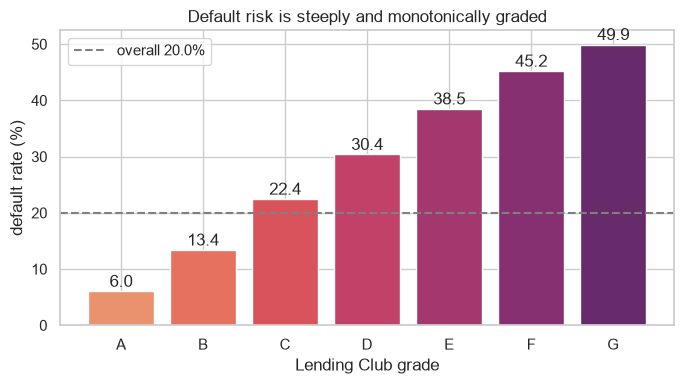

In [2]:
g = loans.groupby("grade")["default"].agg(rate="mean", n="size")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(g.index, g["rate"] * 100, color=sns.color_palette("flare", len(g)))
ax.axhline(overall * 100, ls="--", c="gray",
           label=f"overall {overall:.1%}")
for x, (rate, n) in enumerate(zip(g["rate"], g["n"])):
    ax.text(x, rate * 100 + 0.8, f"{rate * 100:.1f}", ha="center")
ax.set_xlabel("Lending Club grade")
ax.set_ylabel("default rate (%)")
ax.set_title("Default risk is steeply and monotonically graded")
ax.legend()
plt.tight_layout()

## Default rate by loan purpose

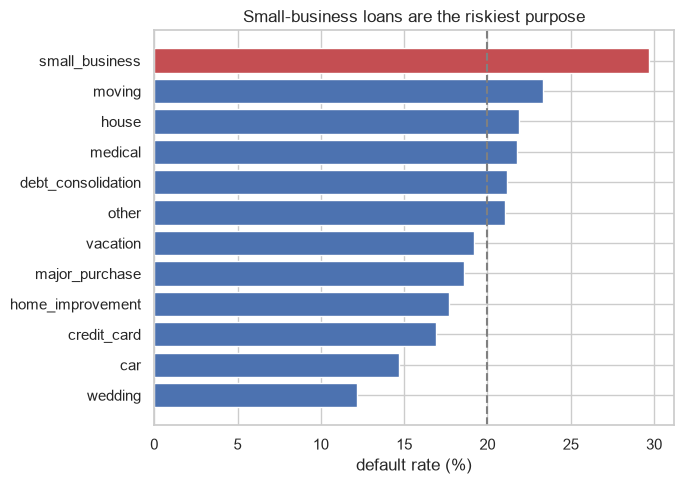

In [3]:
p = (loans.groupby("purpose")["default"].agg(rate="mean", n="size")
          .query("n >= 1000")
          .sort_values("rate"))

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(p.index, p["rate"] * 100,
        color=["#c44e52" if v == p["rate"].max() else "#4c72b0"
               for v in p["rate"]])
ax.axvline(overall * 100, ls="--", c="gray")
ax.set_xlabel("default rate (%)")
ax.set_title("Small-business loans are the riskiest purpose")
plt.tight_layout()

## Issue cohorts — volume and default rate by year

Completed loans only: recent cohorts are **partially censored** (their
still-running loans are excluded), which deflates 2018 and inflates the
share of quick defaults in it.

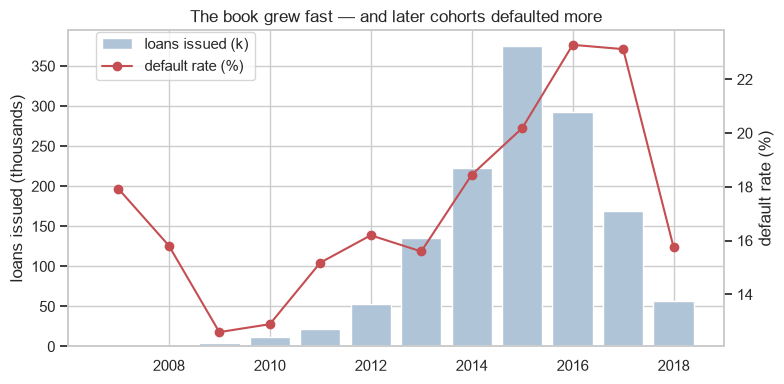

In [4]:
yr = loans.groupby("issue_year")["default"].agg(rate="mean", n="size")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(yr.index, yr["n"] / 1000, color="#b0c4d8", label="loans issued (k)")
ax.set_ylabel("loans issued (thousands)")
ax2 = ax.twinx()
ax2.plot(yr.index, yr["rate"] * 100, "o-", c="#c44e52",
         label="default rate (%)")
ax2.set_ylabel("default rate (%)")
ax2.grid(False)
ax.set_title("The book grew fast — and later cohorts defaulted more")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()

## Interest rate by outcome — pricing separates the classes, partially

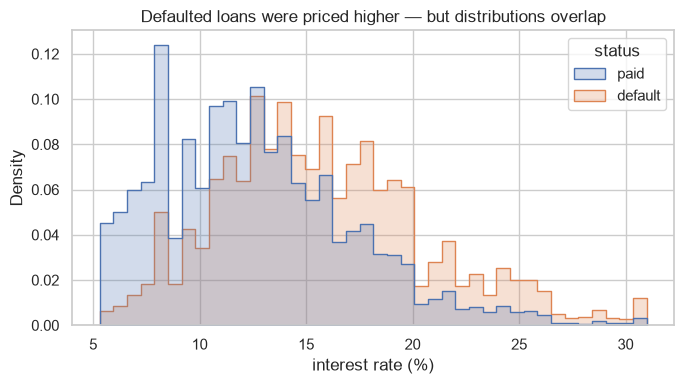

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=loans, x="int_rate", hue="status", bins=40,
             stat="density", common_norm=False, element="step", ax=ax)
ax.set_xlabel("interest rate (%)")
ax.set_title("Defaulted loans were priced higher — but distributions overlap")
plt.tight_layout()

## Loan-to-income ratio — the engineered feature, validated

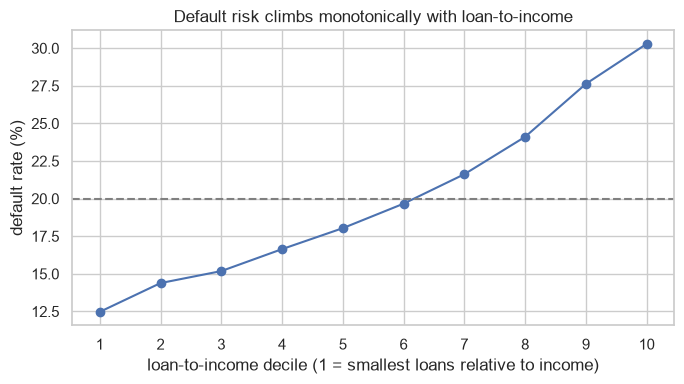

In [6]:
ok = loans[loans["annual_income"] > 0].copy()
ok["lti_decile"] = pd.qcut(ok["amount"] / ok["annual_income"],
                           10, labels=False) + 1
lti = ok.groupby("lti_decile")["default"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lti.index, lti.values, "o-", c="#4c72b0")
ax.axhline(overall * 100, ls="--", c="gray")
ax.set_xticks(range(1, 11))
ax.set_xlabel("loan-to-income decile (1 = smallest loans relative to income)")
ax.set_ylabel("default rate (%)")
ax.set_title("Default risk climbs monotonically with loan-to-income")
plt.tight_layout()

## FICO at issue vs. default

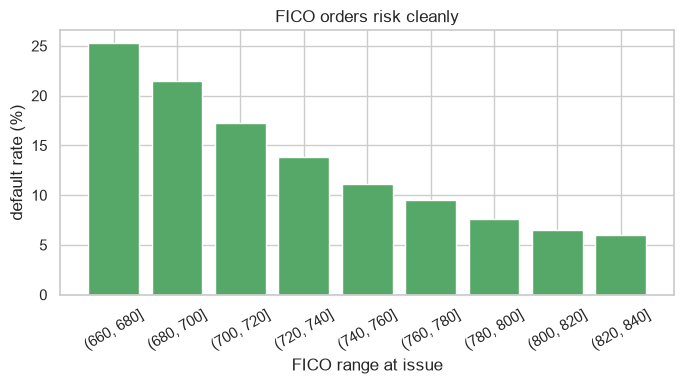

In [7]:
fico = (loans.groupby(pd.cut(loans["fico"], bins=range(660, 860, 20)),
                      observed=True)["default"]
             .agg(rate="mean", n="size"))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(i) for i in fico.index], fico["rate"] * 100, color="#55a868")
ax.set_xlabel("FICO range at issue")
ax.set_ylabel("default rate (%)")
ax.set_title("FICO orders risk cleanly")
plt.xticks(rotation=30)
plt.tight_layout()

## Takeaways

- **Grade is the dominant single signal** — 6.0% (A) to 49.9% (G), perfectly
  monotonic. Interest-rate pricing tracks it but does not fully offset the
  realized losses in low grades.
- **Loan-to-income** is a clean monotonic driver (12.5% → 30.3% across
  deciles) — worth engineering as a model feature.
- **FICO and income** order risk as expected; **purpose** matters
  (small business ~30%); **employment length barely matters**.
- Cohort default rates rose as volume scaled 2014–2017 — and the censoring
  caveat applies to the newest cohorts.

Next: `model.ipynb` turns these signals into a default-probability model.